# **종합실습 : 이진분류**

* 회사 인사팀에서는 여러분들에게 직원의 이직여부과 관련해서 분석을 요청하였습니다.
* 최근 이직율이 증가하는 것에 대해 우려를 갖고 있기에, 이직여부에 영향을 주는 요인에 대해 분석하여, 이직할 것으로 보이는 직원들에 대해 회사를 떠나지 않도록 인사 프로그램을 준비하려고 합니다.
* 어떤 직원이 이직할지 예측해 봅시다.

![](https://adoptostaging.blob.core.windows.net/media/employee-attrition-reasons-9LIqMv.jpg)


## **1.환경준비**

### (1) 라이브러리 Import

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [20]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

### (2) 필요 함수 생성

### (2) 필요 함수 생성

* 딥러닝을 위한 데이터로더 만들기

In [21]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :

    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

    # TensorDataset 생성 : 텐서 데이터셋으로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)

    return train_loader, x_val_tensor, y_val_tensor

* 학습을 위한 함수

In [22]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)                  # 전체 데이터셋의 크기
    num_batches = len(dataloader)                   # 배치 크기
    tr_loss = 0
    model.train()                                   # 훈련 모드로 설정(드롭아웃 및 배치 정규화와 같은 계층을 훈련 모드로 변경)
    for batch, (X, y) in enumerate(dataloader):     # batch : 현재 배치 번호, (X, y) : 입력 데이터와 레이블
        X, y = X.to(device), y.to(device)           # X.to(device), y.to(device): 입력 데이터와 레이블을 지정된 장치(device, CPU 또는 GPU)로 이동

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation
        loss.backward()             # 역전파를 통해 모델의 각 파라미터에 대한 손실의 기울기를 계산
        optimizer.step()            # 옵티마이저가 계산된 기울기를 사용하여 모델의 파라미터를 업데이트
        optimizer.zero_grad()       # 옵티마이저의 기울기 값 초기화. 기울기가 누적되는 것 방지

    tr_loss /= num_batches          # 모든 배치에서의 loss 평균

    return tr_loss.item()

* 검증을 위한 함수

In [23]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval()                        # 모델을 평가 모드로 설정

    with torch.no_grad():               # 평가 과정에서 기울기를 계산하지 않도록 설정(메모리 사용을 줄이고 평가 속도를 높입니다.)
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item()    # 예측 값 pred와 실제 값 y 사이의 손실 계산

    return eval_loss, pred

* 학습곡선

In [24]:
def dl_learning_curve(tr_loss_list, val_loss_list):

    epochs = list(range(1, len(tr_loss_list)+1))
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.')
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (3) device 준비(cpu or gpu)

In [25]:
# cpu 혹은 gpu 사용
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


### (4) 데이터로딩

In [26]:
path = "https://raw.githubusercontent.com/DA4BAM/dataset/master/Attrition_train_validation.CSV"
data = pd.read_csv(path)
data['Attrition'] = np.where(data['Attrition']=='Yes', 1, 0)
data.head(10)

,Attrition,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,OverTime,PercentSalaryHike,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager
0,0,33,Travel_Rarely,Research & Development,7,3,Medical,817,3,Male,...,No,11,4,0,14,3,4,13,9,7
1,0,35,Travel_Frequently,Research & Development,18,2,Life Sciences,1412,3,Male,...,No,11,3,0,10,2,3,2,2,2
2,0,42,Travel_Rarely,Research & Development,6,3,Medical,1911,3,Male,...,No,13,2,1,18,3,4,13,7,7
3,0,46,Travel_Rarely,Sales,2,3,Marketing,1204,3,Female,...,No,23,1,0,28,2,3,26,15,9
4,0,39,Travel_Frequently,Sales,20,3,Life Sciences,1812,3,Male,...,No,18,4,1,7,6,3,2,1,2
5,1,22,Travel_Frequently,Research & Development,4,1,Technical Degree,593,3,Male,...,No,16,3,0,4,3,3,2,2,2
6,0,24,Travel_Rarely,Research & Development,21,2,Technical Degree,1551,3,Male,...,No,14,2,3,2,3,3,1,1,0
7,0,34,Travel_Rarely,Research & Development,8,3,Medical,2068,2,Male,...,No,12,1,0,6,3,4,4,3,2
8,0,30,Travel_Rarely,Research & Development,20,3,Other,1084,3,Male,...,No,15,3,1,7,1,2,6,2,2
9,0,26,Travel_Rarely,Research & Development,6,3,Life Sciences,686,3,Female,...,Yes,13,3,1,3,2,3,3,2,2


|	변수 명	|	내용	|	구분	|
|	----	|	----	|	----	|
|	**Attrition**	|	이직여부, Yes = 1 , No = 0	|	**Target**	|
|	Age	|	나이	|	숫자	|
|	BusinessTravel	|	출장 빈도(범주)	|		|
|	Department	|	현 부서	|		|
|	DistanceFromHome	|	집-직장 거리(마일)	|	숫자	|
|	Education	|	교육수준(범주)	|	1 Below College, 2 College, 3 Bachelor, 4 Master, 5 Doctor	|
|	EducationField	|	전공	|		|
|	EmployeeNumber	|	사번	|		|
|	EnvironmentSatisfaction	|	근무환경에 대한 만족도(범주)	|	1 Low, 2 Good, 3 Excellent, 4 Outstanding	|
|	Gender	|	성별	|		|
|	JobInvolvement	|	직무 적극성(참여도)	|	1 Low, 2 Medium, 3 High, 4 Very High	|
|	JobRole	|	직무	|		|
|	JobSatisfaction	|	직무 만족도	|	1 Low, 2 Medium, 3 High, 4 Very High	|
|	MaritalStatus	|	결혼상태	| Single, Married, Divorced		|
|	MonthlyIncome	|	월급	|	숫자	|
|	NumCompaniesWorked	|	현재까지 근무한 회사 수	|	숫자	|
|	OverTime	|	야근여부	|	범주	|
|	PercentSalaryHike	|	전년대비 급여인상율(%)	|	숫자	|
|	RelationshipSatisfaction	|	동료와의 관계 만족도	|	1 Low, 2 Medium, 3 High, 4 Very High	|
|	StockOptionLevel	|	스톡옵션 수준 0~3	|	범주	|
|	TotalWorkingYears	|	총 근무 연수	|	숫자	|
|	TrainingTimesLastYear	|	전년 교육훈련 횟수	|	숫자	|
|	WorkLifeBalance	|	워라밸. 일-삶 균형도	|	1 Bad, 2 Good, 3 Better, 4 Best	|
|	YearsAtCompany	|	현직장 근무 연수	|	숫자	|
|	YearsInCurrentRole	|	현직무 연수	|	숫자	|
|	YearsWithCurrManager	|	현 팀장과 근무한 연수	|	숫자	|


## **2.데이터 준비**

### (1) 데이터 준비
* x, y 나누기
    * x : lstat, ptratio, crim
    * y : medv

In [27]:
target = 'Attrition'
x = data.drop(target, axis = 1)
y = data.loc[:, target]

### (2) 가변수화

In [28]:
x = pd.get_dummies(x, drop_first=True, dtype=float)
x.head()

,Age,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,33,7,3,817,3,3,3,11691,0,11,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,35,18,2,1412,3,3,4,9362,2,11,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,42,6,3,1911,3,3,1,13348,9,13,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,46,2,3,1204,3,3,1,17048,8,23,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,39,20,3,1812,3,3,4,4127,2,18,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### (3) 데이터분할

In [29]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.2, random_state = 20)

### (4) Scaling

In [30]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)

### (5) 텐서로 변환, 데이터로더 준비

In [31]:
train_loader, x_val_tesor, y_val_tensor = make_DataSet(x_train, x_val, y_train, y_val, 32)

In [32]:
# 첫번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f"Shape of x [rows, columns]: {x.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of x [rows, columns]: torch.Size([32, 39])
Shape of y: torch.Size([32, 1]) torch.float32


## **3.모델링1**

### (1) 모델 선언

In [33]:
n_feature = x.shape[1]

model = nn.Sequential(
    nn.Linear(n_feature, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
).to(device)

In [36]:
n_feature = x.shape[1]

model2 = nn.Sequential(
    nn.Linear(n_feature, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid()
).to(device)

In [34]:
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)

In [37]:
loss_fn = nn.BCELoss()
optimizer = Adam(model2.parameters(), lr=0.01)

### (2) 학습

In [35]:
epochs = 50
tr_loss_list = []
val_loss_list = []

for i in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val_tesor, y_val_tensor, model, loss_fn, device)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {i+1}/{epochs} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/50 | Train Loss: 0.4345 | Val Loss: 0.3541
Epoch 2/50 | Train Loss: 0.3588 | Val Loss: 0.3437
Epoch 3/50 | Train Loss: 0.3298 | Val Loss: 0.2768
Epoch 4/50 | Train Loss: 0.3387 | Val Loss: 0.3195
Epoch 5/50 | Train Loss: 0.3355 | Val Loss: 0.2888
Epoch 6/50 | Train Loss: 0.3220 | Val Loss: 0.2775
Epoch 7/50 | Train Loss: 0.3063 | Val Loss: 0.3138
Epoch 8/50 | Train Loss: 0.3159 | Val Loss: 0.3841
Epoch 9/50 | Train Loss: 0.3100 | Val Loss: 0.2716
Epoch 10/50 | Train Loss: 0.2901 | Val Loss: 0.2932
Epoch 11/50 | Train Loss: 0.2775 | Val Loss: 0.2919
Epoch 12/50 | Train Loss: 0.2813 | Val Loss: 0.2744
Epoch 13/50 | Train Loss: 0.2720 | Val Loss: 0.2819
Epoch 14/50 | Train Loss: 0.2820 | Val Loss: 0.2920
Epoch 15/50 | Train Loss: 0.2528 | Val Loss: 0.2863
Epoch 16/50 | Train Loss: 0.2622 | Val Loss: 0.2606
Epoch 17/50 | Train Loss: 0.2413 | Val Loss: 0.3279
Epoch 18/50 | Train Loss: 0.2341 | Val Loss: 0.2780
Epoch 19/50 | Train Loss: 0.2117 | Val Loss: 0.3070
Epoch 20/50 | Train L

In [38]:
epochs = 100
tr_loss_list = []
val_loss_list = []

for i in range(epochs):
    tr_loss = train(train_loader, model2, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val_tesor, y_val_tensor, model2, loss_fn, device)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {i+1}/{epochs} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/100 | Train Loss: 0.4454 | Val Loss: 0.4027
Epoch 2/100 | Train Loss: 0.3690 | Val Loss: 0.3244
Epoch 3/100 | Train Loss: 0.3549 | Val Loss: 0.3363
Epoch 4/100 | Train Loss: 0.3240 | Val Loss: 0.2846
Epoch 5/100 | Train Loss: 0.3100 | Val Loss: 0.3286
Epoch 6/100 | Train Loss: 0.3174 | Val Loss: 0.2608
Epoch 7/100 | Train Loss: 0.3076 | Val Loss: 0.2652
Epoch 8/100 | Train Loss: 0.2915 | Val Loss: 0.2698
Epoch 9/100 | Train Loss: 0.2936 | Val Loss: 0.2912
Epoch 10/100 | Train Loss: 0.2969 | Val Loss: 0.2821
Epoch 11/100 | Train Loss: 0.2735 | Val Loss: 0.2662
Epoch 12/100 | Train Loss: 0.2628 | Val Loss: 0.2937
Epoch 13/100 | Train Loss: 0.2467 | Val Loss: 0.2763
Epoch 14/100 | Train Loss: 0.2345 | Val Loss: 0.3284
Epoch 15/100 | Train Loss: 0.2413 | Val Loss: 0.2890
Epoch 16/100 | Train Loss: 0.2155 | Val Loss: 0.3369
Epoch 17/100 | Train Loss: 0.1932 | Val Loss: 0.2888
Epoch 18/100 | Train Loss: 0.1812 | Val Loss: 0.4169
Epoch 19/100 | Train Loss: 0.1926 | Val Loss: 0.3189
Ep

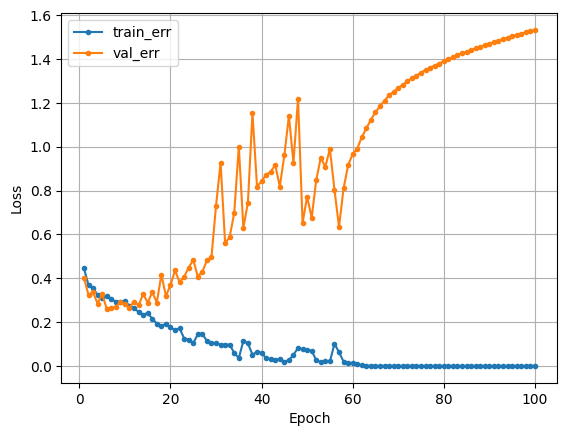

In [39]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 모델 평가

In [40]:
pred.numpy()[:5]

array([[6.9557577e-03],
       [2.3811333e-15],
       [7.4042259e-07],
       [1.4821177e-09],
       [0.0000000e+00]], dtype=float32)

In [41]:
pred = np.where(pred.numpy() >= 0.5, 1, 0)
pred

array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
    

In [43]:
print(classification_report(y_val_tensor.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.92      0.94      0.93       214
         1.0       0.59      0.53      0.56        36

    accuracy                           0.88       250
   macro avg       0.76      0.73      0.74       250
weighted avg       0.87      0.88      0.88       250



## **4.모델링2**

### (1) 모델 선언

In [45]:
n_feature = x.shape[1]

model3 = nn.Sequential(
    nn.Linear(n_feature, 128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 8),
    nn.Linear(8, 1),
    nn.Sigmoid()
).to(device)

In [46]:
loss_fn = nn.BCELoss()
optimizer = Adam(model3.parameters(), lr=0.01, weight_decay=1e-4)

### (2) 학습

In [47]:
epochs = 20
tr_loss_list = []
val_loss_list = []

for i in range(epochs):
    tr_loss = train(train_loader, model3, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val_tesor, y_val_tensor, model3, loss_fn, device)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {i+1}/{epochs} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/20 | Train Loss: 0.4138 | Val Loss: 0.3253
Epoch 2/20 | Train Loss: 0.3898 | Val Loss: 0.4388
Epoch 3/20 | Train Loss: 0.3858 | Val Loss: 0.3413
Epoch 4/20 | Train Loss: 0.3684 | Val Loss: 0.3673
Epoch 5/20 | Train Loss: 0.3522 | Val Loss: 0.3074
Epoch 6/20 | Train Loss: 0.3376 | Val Loss: 0.2978
Epoch 7/20 | Train Loss: 0.3361 | Val Loss: 0.2814
Epoch 8/20 | Train Loss: 0.3420 | Val Loss: 0.2950
Epoch 9/20 | Train Loss: 0.3300 | Val Loss: 0.3065
Epoch 10/20 | Train Loss: 0.3187 | Val Loss: 0.2812
Epoch 11/20 | Train Loss: 0.3046 | Val Loss: 0.2944
Epoch 12/20 | Train Loss: 0.3145 | Val Loss: 0.3223
Epoch 13/20 | Train Loss: 0.3199 | Val Loss: 0.2968
Epoch 14/20 | Train Loss: 0.2964 | Val Loss: 0.2948
Epoch 15/20 | Train Loss: 0.2912 | Val Loss: 0.2719
Epoch 16/20 | Train Loss: 0.2750 | Val Loss: 0.2887
Epoch 17/20 | Train Loss: 0.2734 | Val Loss: 0.3213
Epoch 18/20 | Train Loss: 0.2750 | Val Loss: 0.2890
Epoch 19/20 | Train Loss: 0.2464 | Val Loss: 0.2886
Epoch 20/20 | Train L

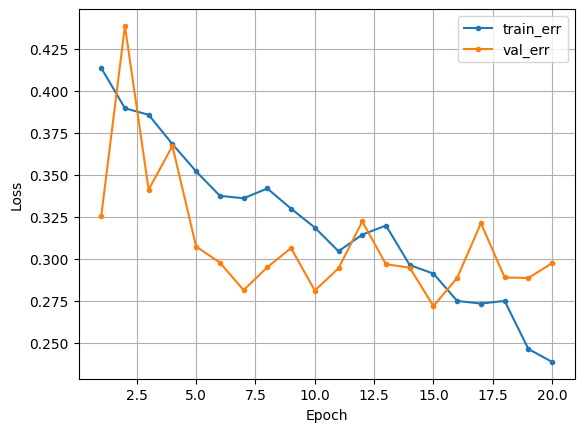

In [48]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 모델 평가

In [49]:
pred.numpy()[:5]

array([[1.7879036e-01],
       [7.2277732e-02],
       [5.9923013e-03],
       [3.2413998e-01],
       [3.4807394e-07]], dtype=float32)

In [50]:
pred = np.where(pred.numpy() >= 0.5, 1, 0)

In [51]:
print(classification_report(y_val_tensor.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94       214
         1.0       0.87      0.36      0.51        36

    accuracy                           0.90       250
   macro avg       0.88      0.68      0.73       250
weighted avg       0.90      0.90      0.88       250



## **5.모델링3**

### (1) 모델 선언

In [53]:
n_feature = x.shape[1]

model4 = nn.Sequential(
    nn.Linear(n_feature, 128),
    nn.ReLU(),
    nn.Linear(128,64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
).to(device)

In [54]:
loss_fn = nn.BCELoss()
optimizer = Adam(model4.parameters(), lr=0.01, weight_decay=1e-4)

### (2) 학습

In [55]:
epochs = 20
tr_loss_list, val_loss_list= [], []

for i in range(epochs):
    tr_loss = train(train_loader, model4, loss_fn, optimizer, device)
    val_loss, pred = evaluate(x_val_tesor, y_val_tensor, model4, loss_fn, device)

    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {i+1}/{epochs} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/20 | Train Loss: 0.4786 | Val Loss: 0.3510
Epoch 2/20 | Train Loss: 0.3994 | Val Loss: 0.3325
Epoch 3/20 | Train Loss: 0.3461 | Val Loss: 0.3204
Epoch 4/20 | Train Loss: 0.3726 | Val Loss: 0.3086
Epoch 5/20 | Train Loss: 0.3498 | Val Loss: 0.3173
Epoch 6/20 | Train Loss: 0.3764 | Val Loss: 0.3178
Epoch 7/20 | Train Loss: 0.3490 | Val Loss: 0.2928
Epoch 8/20 | Train Loss: 0.3335 | Val Loss: 0.2820
Epoch 9/20 | Train Loss: 0.3310 | Val Loss: 0.2885
Epoch 10/20 | Train Loss: 0.3121 | Val Loss: 0.2813
Epoch 11/20 | Train Loss: 0.3296 | Val Loss: 0.2999
Epoch 12/20 | Train Loss: 0.3091 | Val Loss: 0.2662
Epoch 13/20 | Train Loss: 0.3429 | Val Loss: 0.2728
Epoch 14/20 | Train Loss: 0.3581 | Val Loss: 0.2766
Epoch 15/20 | Train Loss: 0.3179 | Val Loss: 0.3065
Epoch 16/20 | Train Loss: 0.3236 | Val Loss: 0.3446
Epoch 17/20 | Train Loss: 0.3144 | Val Loss: 0.2824
Epoch 18/20 | Train Loss: 0.2893 | Val Loss: 0.2533
Epoch 19/20 | Train Loss: 0.2760 | Val Loss: 0.2679
Epoch 20/20 | Train L

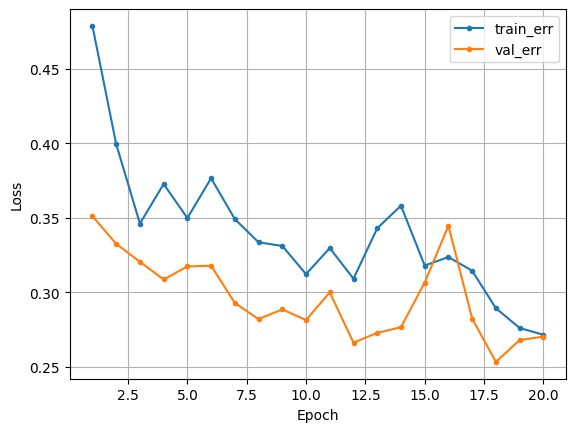

In [56]:
dl_learning_curve(tr_loss_list, val_loss_list)

### (3) 모델 평가

In [57]:
pred.numpy()[:5]

array([[9.6542761e-02],
       [1.1376420e-01],
       [6.3029458e-03],
       [3.5215724e-01],
       [3.9696056e-07]], dtype=float32)

In [67]:
pred = np.where(pred.numpy() >= 0.5, 1, 0)

              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94       214
         1.0       0.65      0.47      0.55        36

    accuracy                           0.89       250
   macro avg       0.78      0.72      0.74       250
weighted avg       0.88      0.89      0.88       250



In [64]:
print(classification_report(y_val_tensor.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94       214
         1.0       0.65      0.47      0.55        36

    accuracy                           0.89       250
   macro avg       0.78      0.72      0.74       250
weighted avg       0.88      0.89      0.88       250

